# utils.utils

`plot_misc.utils.utils` collects small helpers for figure formatting and annotation that the plot modules build on. This TLDR demonstrates each public helper in isolation; see the worked-out `utils` example for detailed parameter walkthroughs.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plot_misc.example_data.examples as examples
import plot_misc.utils.utils as pm_utils

CMTOINCH = 1 / 2.54

## MidpointNormalize

A `matplotlib` normaliser that anchors a chosen value (e.g. zero) at the centre of a diverging colour map, even when the data range is asymmetric. The left panel below uses matplotlib's default linear normalisation — zero drifts off the white centre because the range is asymmetric (-2 .. 5); the right panel pins white to zero with `MidpointNormalize`.

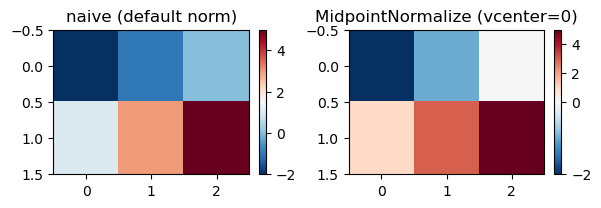

In [2]:
# signed data with an asymmetric range (-2 .. 5)
data = np.array([[-2, -1, 0], [1, 3, 5]], dtype=float)

fig, (ax_naive, ax_mid) = plt.subplots(
    1, 2, figsize=(15 * CMTOINCH, 5 * CMTOINCH), layout="constrained"
)

# naive: default linear normalisation maps data min/max to the colour map
# ends, so zero lands left-of-centre (pale red) rather than white
im0 = ax_naive.imshow(data, cmap="RdBu_r", aspect="auto")
fig.colorbar(im0, ax=ax_naive)
ax_naive.set_title("naive (default norm)")

# MidpointNormalize: vcenter=0 keeps white at zero despite the asymmetry
norm = pm_utils.MidpointNormalize(vmin=-2, vmax=5, vcenter=0)
im1 = ax_mid.imshow(data, cmap="RdBu_r", norm=norm, aspect="auto")
fig.colorbar(im1, ax=ax_mid)
_ = ax_mid.set_title("MidpointNormalize (vcenter=0)")

## plot_span

Shade a horizontal (`axhspan`) or vertical (`axvspan`) band on an axis. Extra kwargs pass straight through to matplotlib.

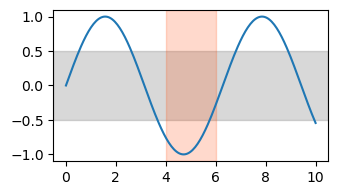

In [3]:
x = np.linspace(0, 10, 200)
fig, ax = plt.subplots(figsize=(9 * CMTOINCH, 5 * CMTOINCH))
ax.plot(x, np.sin(x))
# horizontal band (axhspan)
pm_utils.plot_span(-0.5, 0.5, ax=ax, horizontal=True, color="grey", alpha=0.3)
# vertical band (axvspan)
_ = pm_utils.plot_span(4, 6, ax=ax, horizontal=False, color="orangered", alpha=0.2)

## change_ticks

Set tick locations and labels in one call. With `log=True` the ticks are placed on a `np.log` scale while the labels keep the original (human-readable) values — compare the raw log-valued ticks (left) with the relabelled axis (right).

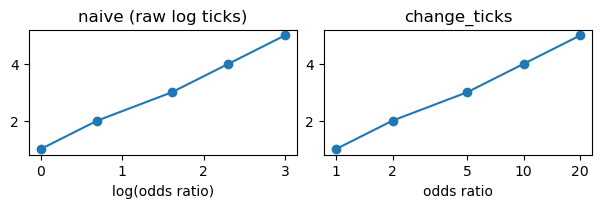

In [4]:
ticks = [1, 2, 5, 10, 20]
fig, (ax_naive, ax_fixed) = plt.subplots(
    1, 2, figsize=(15 * CMTOINCH, 5 * CMTOINCH), layout="constrained"
)
for ax in (ax_naive, ax_fixed):
    ax.plot(np.log(ticks), [1, 2, 3, 4, 5], marker="o")

# naive: the x-axis shows the raw log-transformed positions
ax_naive.set_title("naive (raw log ticks)")
ax_naive.set_xlabel("log(odds ratio)")

# change_ticks: place ticks on the log scale but label the original values
pm_utils.change_ticks(ax_fixed, ticks=ticks, axis="x", log=True)
ax_fixed.set_title("change_ticks")
_ = ax_fixed.set_xlabel("odds ratio")

## calc_matrices

Turn a long-format results table (exposure, outcome, point estimate, p-value) into heatmap-ready matrices. P-values are always `-log10` transformed, exposing three numeric value tables (signed `-log10`, unsigned `-log10`, and raw p) plus matching string-annotation layers (symbols, p-values, or effect sizes). `alpha` and `ptrun` are raw p-values in (0, 1]. The result is returned on a small container object; every matrix it exposes is shown below.

In [5]:
data = examples.get_data("heatmap_data")
res = pm_utils.calc_matrices(
    data,
    exposure_col="exposure",
    outcome_col="outcome",
    point_col="point",
    pvalue_col="pvalue",
    annotate="symbol",
    dropna=True,
)
# every matrix exposed on the results object, with a one-line description
tables = {
    "curated_matrix_value": "signed -log10(p) matrix used for colour (NA-masked with 0).",
    "curated_matrix_value_unsigned_log": "unsigned -log10(p) matrix (NA-masked with 0).",
    "curated_matrix_value_raw": "raw p-value matrix (NA-masked with 1).",
    "curated_matrix_annotation": "string matrix (here significance symbols).",
    "curated_matrix_point_estimate_value": "same as the value matrix but holding the original point estimates.",
    "crude_point_estimate": "raw point-estimate matrix before any formatting or masking.",
    "matrix_pvalue": "p-value annotation strings (signed -log10 p), non-significant cells masked.",
    "matrix_star": "symbols for significant cells, masked elsewhere.",
    "matrix_point_estimate": "formatted point estimates as strings, non-significant cells masked.",
    "source_data": "the original long-format input, kept for provenance.",
}
for name, description in tables.items():
    print(f"{name} — {description}")
    display(getattr(res, name))

curated_matrix_value — signed -log10(p) matrix used for colour (NA-masked with 0).


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,0.60,-0.02,3.27,-0.69
LDL-C,-2.28,4.00,0.00,0.00


curated_matrix_value_unsigned_log — unsigned -log10(p) matrix (NA-masked with 0).


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,0.60,0.02,3.27,0.69
LDL-C,2.28,4.00,0.00,0.00


curated_matrix_value_raw — raw p-value matrix (NA-masked with 1).


...

exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,★,.
LDL-C,★,★,nan,nan


matrix_point_estimate — formatted point estimates as strings, non-significant cells masked.


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,0.03,.
LDL-C,-0.24,0.03,nan,nan


source_data — the original long-format input, kept for provenance.


,id,exposure,outcome,point,pvalue
index,,,,,
ldlc_glgc,ldlc_glgc,SCF,LDL-C,NaN,NaN
hdlc_glgc,hdlc_glgc,SCF,HDL-C,0.027800,0.000534
ldlc_glgc,ldlc_glgc,TRAIL,LDL-C,NaN,NaN
hdlc_glgc,hdlc_glgc,TRAIL,HDL-C,-0.157239,0.204640
ldlc_glgc,ldlc_glgc,IP10,LDL-C,0.032154,0.000100
hdlc_glgc,hdlc_glgc,IP10,HDL-C,-0.025240,0.954260
ldlc_glgc,ldlc_glgc,IL2ra,LDL-C,-0.235300,0.005235
hdlc_glgc,hdlc_glgc,IL2ra,HDL-C,0.023522,0.253530


## adjust_labels

Nudge a list of `ax.annotate` objects apart when they sit closer than `min_distance`, reducing overlap of crowded labels.

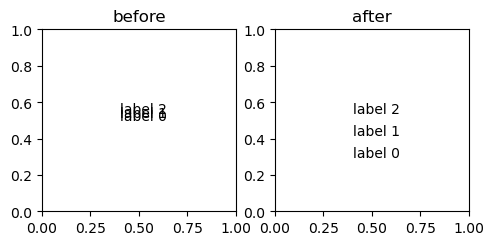

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14 * CMTOINCH, 6 * CMTOINCH))
for ax, title, adjust in zip(axes, ["before", "after"], [False, True]):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    anns = [
        ax.annotate(f"label {i}", (0.4, 0.50 + 0.02 * i)) for i in range(3)
    ]
    if adjust:
        # one pass nudges pairs apart; repeat until positions stabilise
        for _ in range(5):
            pm_utils.adjust_labels(anns, axis=ax, min_distance=0.12)

## calc_mid_point & calc_angle_points

Small geometry helpers: the Cartesian midpoint between two points, and the angle (degrees or radians) of the segment joining them.

In [7]:
x = (1.0, 4.0)
y = (2.0, 6.0)
print("midpoint   :", pm_utils.calc_mid_point(x, y))
print("angle (deg):", round(pm_utils.calc_angle_points(x, y), 1))
print("angle (rad):", round(pm_utils.calc_angle_points(x, y, radians=True), 3))

midpoint   : (2.5, 4.0)
angle (deg): 53.1
angle (rad): 0.927


## segment_labelled

Draw a line segment between two points with styled endpoints and an optional label at its midpoint. By default the label is **rotated to follow the segment**: internally `segment_labelled` measures the segment's on-screen angle with `calc_angle_points` and applies it as the text rotation. Pass `overrule_angle` to force a fixed rotation instead (e.g. `0` for horizontal), or `calc_angle_after_trans=False` to rotate by the data-coordinate angle rather than the displayed angle.

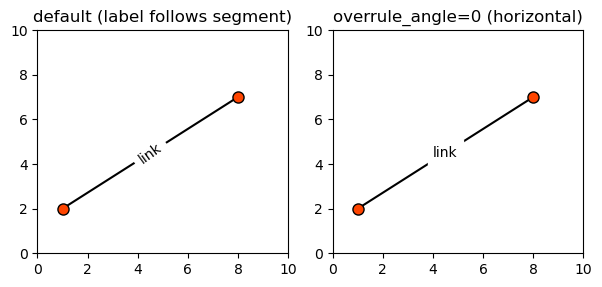

In [8]:
fig, (ax_auto, ax_flat) = plt.subplots(
    1, 2, figsize=(15 * CMTOINCH, 7 * CMTOINCH), layout="constrained"
)
for ax in (ax_auto, ax_flat):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

# default: the label rotation follows the segment (angle computed internally)
pm_utils.segment_labelled(
    x=(1, 8), y=(2, 7), ax=ax_auto, label="link", endpoints_c="orangered"
)
ax_auto.set_title("default (label follows segment)")

# overrule_angle pins the label to a fixed rotation (0 = horizontal)
pm_utils.segment_labelled(
    x=(1, 8), y=(2, 7), ax=ax_flat, label="link", endpoints_c="orangered",
    overrule_angle=0,
)
_ = ax_flat.set_title("overrule_angle=0 (horizontal)")